#  Symptom Checker with Medical Text Classification

## Import Libraries

In [53]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GRU, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import re
import string
import nltk
import seaborn as sns
from datasets import load_dataset
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
from keras.optimizers import Adam

## Load dataset

In [54]:
nltk.download('stopwords')
nltk.download('wordnet')

# Load dataset from Hugging Face
dataset = load_dataset("mohammad2928git/complete_medical_symptom_dataset")
df = pd.DataFrame(dataset['train'][:50000])

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [55]:
df.columns

Index(['text', 'label', 'symptoms', 'lebel_text', 'Code', 'Name', 'Symptoms',
       'Treatments', 'AGE', 'DIFFERENTIAL_DIAGNOSIS', 'SEX', 'PATHOLOGY',
       'EVIDENCES', 'INITIAL_EVIDENCE'],
      dtype='object')

In [56]:
columns_to_keep = ['symptoms', 'lebel_text']
df = df[columns_to_keep]

# Basic data exploration
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns}")
print("\nSample data:")
print(df.head())

Dataset shape: (50000, 2)
Columns: Index(['symptoms', 'lebel_text'], dtype='object')

Sample data:
                                            symptoms  \
0  [migraines headaches,  can't sleep,  whole bod...   
1  [asthma wheezing breathing problems,  fevers, ...   
2  [signs symptoms primary ovarian insufficiency ...   
3  [cough, high fever, breathlessness, family his...   
4  [chills, vomiting, high fever, sweating, heada...   

                    lebel_text  
0              [drug reaction]  
1                    [allergy]  
2  [premature ovarian failure]  
3           [bronchial asthma]  
4                    [malaria]  


## Clean and preprocess dataset

In [57]:
# Create a text field by combining symptoms
df['symptoms_text'] = df['symptoms'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)
df.dropna(subset=['symptoms'], inplace=True)

In [58]:
df.columns = ['symptoms', 'disease', 'symptoms_text']
print(df.columns)

Index(['symptoms', 'disease', 'symptoms_text'], dtype='object')


In [59]:
null_counts = df.isnull().sum()
null_counts

symptoms         0
disease          0
symptoms_text    0
dtype: int64

In [61]:
# Text Preprocessing Function
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = ''.join([char for char in text if char not in string.punctuation])
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Tokenize
    tokens = text.split()
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]
    
    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    return ' '.join(tokens)

In [62]:
# Apply preprocessing
df['processed_symptoms'] = df['symptoms_text'].apply(preprocess_text)

In [63]:
# Handle class imbalance with class weights
df['disease'] = df['disease'].apply(lambda x: x[0] if isinstance(x, list) else x)
disease_counts = Counter(df['disease'])
total_samples = len(df)
class_weights = {label: total_samples / (len(disease_counts) * count) 
                 for label, count in disease_counts.items()}

In [64]:
# Encode labels
label_encoder = LabelEncoder()
df['disease_encoded'] = label_encoder.fit_transform(df['disease'])
num_classes = len(label_encoder.classes_)

## Visualize dataset

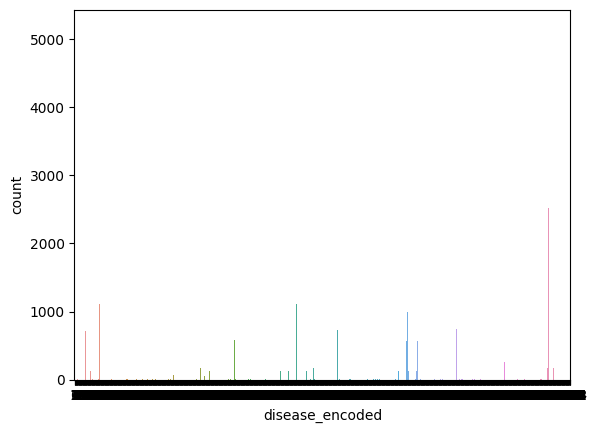

In [65]:
# Check class distribution
sns.countplot(x=df['disease_encoded'])
plt.show()

# Apply SMOTE for oversampling
X = df['symptoms']
y = df['disease_encoded']


In [66]:
import json
# Save mapping for later reference
disease_mapping = dict(zip(range(len(label_encoder.classes_)), label_encoder.classes_))
with open('disease_mapping.json', 'w') as f:
    json.dump(disease_mapping, f)

In [67]:
# Tokenize symptoms
max_features = 10000 
tokenizer = Tokenizer(num_words=max_features, oov_token='<OOV>')
tokenizer.fit_on_texts(df['processed_symptoms'])

In [69]:
# Convert text to sequences
X_sequences = tokenizer.texts_to_sequences(df['processed_symptoms'])

# Pad sequences to ensure uniform length
max_len = 50  
X_padded = pad_sequences(X_sequences, maxlen=max_len, padding='post')

# One-hot encode target variable
y_encoded = to_categorical(df['disease_encoded'])

## Split Dataset

In [70]:
# Train-test split 
X_train, X_test, y_train, y_test = train_test_split(
    X_padded, y_encoded, test_size=0.3, random_state=42
)

In [71]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(35000, 50)
(15000, 50)
(35000, 1375)
(15000, 1375)


## Buil GRU model

In [72]:
# Create model (GRU version)
def create_gru_model():
    model = Sequential()
    model.add(Embedding(max_features, 128, input_shape=(max_len,)))  
    model.add(Bidirectional(GRU(64, return_sequences=True)))
    model.add(Dropout(0.3))
    model.add(Bidirectional(GRU(32, return_sequences=False)))  
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax'))
    
    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

In [73]:
# Choose model type (GRU or LSTM)
model = create_gru_model()  
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 50, 128)             │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (None, 50, 128)             │          74,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 50, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_4 (Bidirectional)      │ (None, 64)                  │          31,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1375)                │          89,375 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,474,975 (5.63 MB)

 Trainable params: 1,474,975 (5.63 MB)

 Non-trainable params: 0 (0.00 B)

In [74]:
# Define callbacks
model_checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True)

In [75]:
# Convert class_weights dict to format suitable for Keras
class_weight_list = {i: class_weights[label_encoder.inverse_transform([i])[0]] 
                    for i in range(num_classes)}

## GRU Training

In [76]:
# Train the model with class weights to address imbalance
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.3,
    callbacks=[model_checkpoint],
    class_weight=class_weight_list
)

Epoch 1/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.0798 - loss: 6.8602 - val_accuracy: 0.1342 - val_loss: 4.1694
Epoch 2/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.1801 - loss: 6.8848 - val_accuracy: 0.3902 - val_loss: 3.1678
Epoch 3/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.3329 - loss: 5.8449 - val_accuracy: 0.4899 - val_loss: 2.6660
Epoch 4/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.4327 - loss: 5.2211 - val_accuracy: 0.5710 - val_loss: 2.3551
Epoch 5/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.4994 - loss: 4.8118 - val_accuracy: 0.5859 - val_loss: 2.1112
Epoch 6/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5436 - loss: 3.6524 - val_accuracy: 0.6250 - val_loss: 2.0058
Epoch 7/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.5631 - loss: 3.5673 - val_accuracy: 0.6225 - val_loss: 1.9026
Epoch 8/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5898 - loss: 3.0027 - 

## GRU evaluation

In [77]:
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7375 - loss: 1.2515
Test Accuracy: 0.7402


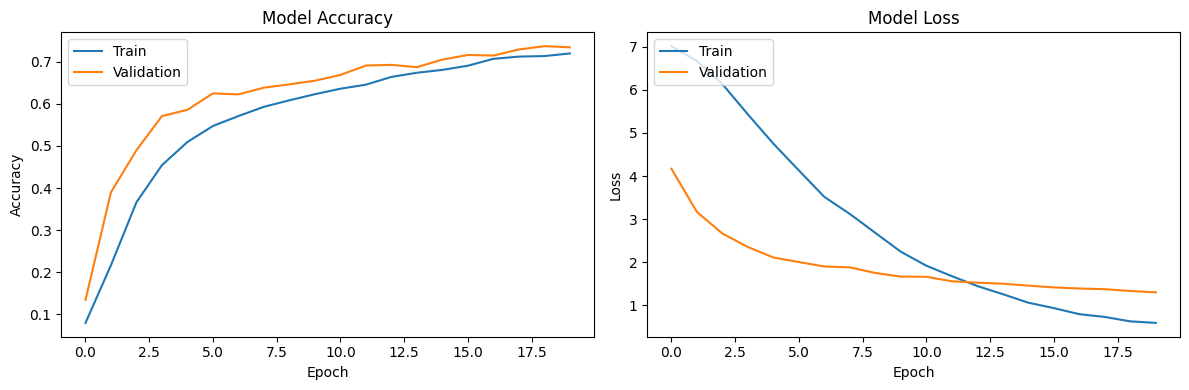

In [78]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

## Prediction using GRU model

In [79]:
def predict_disease(symptoms_text, top_n=3):
    # Preprocess
    processed_text = preprocess_text(symptoms_text)
    # Tokenize
    sequence = tokenizer.texts_to_sequences([processed_text])
    # Pad
    padded_sequence = pad_sequences(sequence, maxlen=max_len, padding='post')
    # Predict
    prediction = model.predict(padded_sequence)[0]
    # Get top N predictions
    top_indices = prediction.argsort()[-top_n:][::-1]
    
    results = []
    for idx in top_indices:
        disease = label_encoder.inverse_transform([idx])[0]
        probability = prediction[idx]
        results.append((disease, probability))
    
    return results

In [96]:
# Example prediction
example_symptoms = "Allergy symptoms, which depend on the substance involved, can affect your airways, sinuses and nasal passages, skin, and digestive system. Allergic reactions can range from mild to severe. In some severe cases, allergies can trigger a life-threatening reaction known as anaphylaxis. Hay fever, also called allergic rhinitis, can cause: Hay fever, Sneezing Itching of the nose, eyes or roof of the mouth Runny, stuffy nose Watery, red or swollen eyes (conjunctivitis) A food allergy can cause: A food allergy Tingling in the mouth Swelling of the lips, tongue, face or throat Hives Anaphylaxis An insect sting allergy can cause: An insect sting allergy A large area of swelling (edema) at the sting site Itching or hives all over the body Cough, chest tightness, wheezing or shortness of breath Anaphylaxis A drug allergy can cause: A drug allergy Hives Itchy skin Rash Facial swelling Wheezing Anaphylaxis Atopic dermatitis, an allergic skin condition also called eczema, can cause skin to: Atopic dermatitis, Itch Redden Flake or peel Anaphylaxis Some types of allergies, including allergies to foods and insect stings, can trigger a severe reaction known as anaphylaxis. A life-threatening medical emergency, anaphylaxis can cause you to go into shock. Signs and symptoms of anaphylaxis include: Loss of consciousness A drop in blood pressure Severe shortness of breath Skin rash Lightheadedness A rapid, weak pulse Nausea and vomiting"
predictions = predict_disease(example_symptoms, top_n=3)
print("\nExample prediction for symptoms:", example_symptoms)
for disease, probability in predictions:
    print(f"{disease}: {probability:.4f}")

# Save the model
model.save('disease_prediction_model.h5')
print("\nModel saved successfully.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

Example prediction for symptoms: Allergy symptoms, which depend on the substance involved, can affect your airways, sinuses and nasal passages, skin, and digestive system. Allergic reactions can range from mild to severe. In some severe cases, allergies can trigger a life-threatening reaction known as anaphylaxis. Hay fever, also called allergic rhinitis, can cause: Hay fever, Sneezing Itching of the nose, eyes or roof of the mouth Runny, stuffy nose Watery, red or swollen eyes (conjunctivitis) A food allergy can cause: A food allergy Tingling in the mouth Swelling of the lips, tongue, face or throat Hives Anaphylaxis An insect sting allergy can cause: An insect sting allergy A large area of swelling (edema) at the sting site Itching or hives all over the body Cough, chest tightness, wheezing or shortness of breath Anaphylaxis A drug allergy can cause: A drug allergy Hives Itchy skin Rash Facial swelling Wheezing Anaphylaxis Atopic dermatitis, an 

## Buil ltsm model

In [81]:
# Create model (LSTM version)
def create_lstm_model():
    model = Sequential()
    model.add(Embedding(max_features, 128, input_shape=(max_len,)))
    model.add(Bidirectional(LSTM(64, return_sequences=False)))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax'))
    
    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

In [82]:
lstm_model = create_lstm_model()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [83]:
lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 50, 128)             │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_5 (Bidirectional)      │ (None, 128)                 │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1375)                │          45,375 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,428,319 (5.45 MB)

 Trainable params: 1,428,319 (5.45 MB)

 Non-trainable params: 0 (0.00 B)

## LSTM training

In [84]:
# Train the model with class weights to address imbalance
history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.3,
    callbacks=[model_checkpoint],
    class_weight=class_weight_list
)

Epoch 1/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.0175 - loss: 7.1813 - val_accuracy: 0.1436 - val_loss: 3.5474
Epoch 2/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.1581 - loss: 6.8719 - val_accuracy: 0.4227 - val_loss: 2.3765
Epoch 3/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3239 - loss: 6.2101 - val_accuracy: 0.5627 - val_loss: 1.9218
Epoch 4/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.2692 - loss: 6.7635 - val_accuracy: 0.6257 - val_loss: 1.7009
Epoch 5/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4614 - loss: 5.9673 - val_accuracy: 0.6612 - val_loss: 1.5193
Epoch 6/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4846 - loss: 5.6420 - val_accuracy: 0.6335 - val_loss: 1.6315
Epoch 7/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4836 - loss: 5.6112 - val_accuracy: 0.6778 - val_loss: 1.5032
Epoch 8/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5285 - loss: 5.0451 - val_acc

## LSTM evaluation

In [85]:
# Evaluate the model
loss, accuracy = lstm_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7286 - loss: 1.3761
Test Accuracy: 0.7301


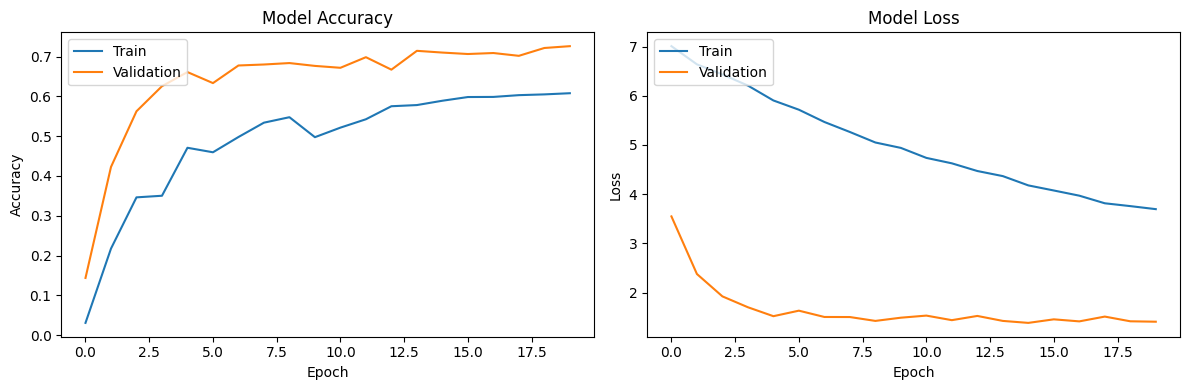

In [86]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['accuracy'])
plt.plot(history_lstm.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

## LSTM prediction

In [97]:
# Example prediction
example_symptoms = "Allergy symptoms, which depend on the substance involved, can affect your airways, sinuses and nasal passages, skin, and digestive system. Allergic reactions can range from mild to severe. In some severe cases, allergies can trigger a life-threatening reaction known as anaphylaxis. Hay fever, also called allergic rhinitis, can cause: Hay fever, Sneezing Itching of the nose, eyes or roof of the mouth Runny, stuffy nose Watery, red or swollen eyes (conjunctivitis) A food allergy can cause: A food allergy Tingling in the mouth Swelling of the lips, tongue, face or throat Hives Anaphylaxis An insect sting allergy can cause: An insect sting allergy A large area of swelling (edema) at the sting site Itching or hives all over the body Cough, chest tightness, wheezing or shortness of breath Anaphylaxis A drug allergy can cause: A drug allergy Hives Itchy skin Rash Facial swelling Wheezing Anaphylaxis Atopic dermatitis, an allergic skin condition also called eczema, can cause skin to: Atopic dermatitis, Itch Redden Flake or peel Anaphylaxis Some types of allergies, including allergies to foods and insect stings, can trigger a severe reaction known as anaphylaxis. A life-threatening medical emergency, anaphylaxis can cause you to go into shock. Signs and symptoms of anaphylaxis include: Loss of consciousness A drop in blood pressure Severe shortness of breath Skin rash Lightheadedness A rapid, weak pulse Nausea and vomiting"
top_n = 3
processed_text = preprocess_text(example_symptoms)
# Tokenize
sequence = tokenizer.texts_to_sequences([example_symptoms])
# Pad
padded_sequence = pad_sequences(sequence, maxlen=max_len, padding='post')
# Predict
prediction = lstm_model.predict(padded_sequence)[0]
# Get top N predictions
top_indices = prediction.argsort()[-top_n:][::-1]

results = []
for idx in top_indices:
    disease = label_encoder.inverse_transform([idx])[0]
    probability = prediction[idx]
    results.append((disease, probability))

print("\nExample prediction for symptoms:", example_symptoms)
for disease, probability in results:
    print(f"{disease}: {probability:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Example prediction for symptoms: Allergy symptoms, which depend on the substance involved, can affect your airways, sinuses and nasal passages, skin, and digestive system. Allergic reactions can range from mild to severe. In some severe cases, allergies can trigger a life-threatening reaction known as anaphylaxis. Hay fever, also called allergic rhinitis, can cause: Hay fever, Sneezing Itching of the nose, eyes or roof of the mouth Runny, stuffy nose Watery, red or swollen eyes (conjunctivitis) A food allergy can cause: A food allergy Tingling in the mouth Swelling of the lips, tongue, face or throat Hives Anaphylaxis An insect sting allergy can cause: An insect sting allergy A large area of swelling (edema) at the sting site Itching or hives all over the body Cough, chest tightness, wheezing or shortness of breath Anaphylaxis A drug allergy can cause: A drug allergy Hives Itchy skin Rash Facial swelling Wheezing Anaphylaxis Atopic dermatitis, an 

In [98]:
# Example prediction
example_symptoms = "fatigue,yellowish_skin,nausea,yellowing_of_eyes,family_history"
top_n = 3
processed_text = preprocess_text(example_symptoms)
# Tokenize
sequence = tokenizer.texts_to_sequences([example_symptoms])
# Pad
padded_sequence = pad_sequences(sequence, maxlen=max_len, padding='post')
# Predict
prediction = lstm_model.predict(padded_sequence)[0]
# Get top N predictions
top_indices = prediction.argsort()[-top_n:][::-1]

results = []
for idx in top_indices:
    disease = label_encoder.inverse_transform([idx])[0]
    probability = prediction[idx]
    results.append((disease, probability))

print("\nExample prediction for symptoms:", example_symptoms)
for disease, probability in results:
    print(f"{disease}: {probability:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Example prediction for symptoms: fatigue,yellowish_skin,nausea,yellowing_of_eyes,family_history
hepatitis c: 0.5792
alcoholic hepatitis: 0.2722
chronic cholestasis: 0.0748
